In [1]:
import pandas as pd

df = pd.read_csv("data/raw/covid-hosp-txad-reg-2023-06-30-16h29.csv", sep=";")

print(df.head())
print(df.shape)
print(df.dtypes)

   reg        jour  PourAvec  tx_indic_7J_DC  tx_indic_7J_hosp  \
0    1  2020-03-07         0             0.0               0.0   
1    1  2020-03-07         1             NaN               0.0   
2    1  2020-03-07         2             NaN               0.0   
3    1  2020-03-08         0             0.0               0.0   
4    1  2020-03-08         1             NaN               0.0   

   tx_indic_7J_SC  tx_prev_hosp  tx_prev_SC  
0             0.0           0.0         0.0  
1             0.0           0.0         0.0  
2             0.0           0.0         0.0  
3             0.0           0.0         0.0  
4             0.0           0.0         0.0  
(65178, 8)
reg                   int64
jour                    str
PourAvec              int64
tx_indic_7J_DC      float64
tx_indic_7J_hosp    float64
tx_indic_7J_SC      float64
tx_prev_hosp        float64
tx_prev_SC          float64
dtype: object


In [2]:
# Filtrer uniquement PourAvec = 0
df_global = df[df["PourAvec"] == 0]
print(df_global.shape)


print(df_global["reg"].nunique())
print(df_global["reg"].unique())


print(df_global["jour"].min())
print(df_global["jour"].max())

(21726, 8)
18
[ 1  2  3  4  6 11 24 27 28 32 44 52 53 75 76 84 93 94]
2020-03-07
2023-06-26


In [3]:
# Trier par date
df_global = df_global.sort_values("jour")

# Moyenne nationale par jour
df_national = df_global.groupby("jour")["tx_prev_SC"].mean()
print(df_national.head(10))
print(df_national.tail(10))

jour
2020-03-07    0.115933
2020-03-08    0.133688
2020-03-09    0.171313
2020-03-10    0.217614
2020-03-11    0.268253
2020-03-12    0.286671
2020-03-13    0.382934
2020-03-14    0.474895
2020-03-15    0.608580
2020-03-16    0.853389
Name: tx_prev_SC, dtype: float64
jour
2023-06-17    0.571475
2023-06-18    0.569021
2023-06-19    0.576378
2023-06-20    0.588079
2023-06-21    0.587782
2023-06-22    0.577790
2023-06-23    0.565161
2023-06-24    0.558220
2023-06-25    0.539031
2023-06-26    0.536740
Name: tx_prev_SC, dtype: float64


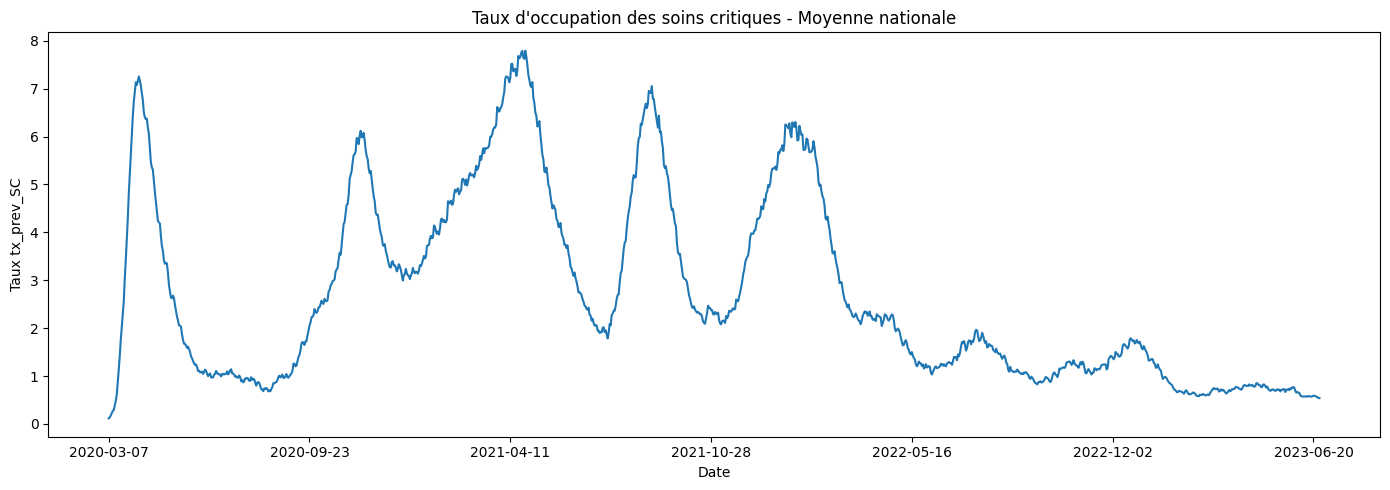

In [5]:
import matplotlib.pyplot as plt

df_national.plot(figsize=(14, 5), title="Taux d'occupation des soins critiques - Moyenne nationale")
plt.xlabel("Date")
plt.ylabel("Taux tx_prev_SC")
plt.tight_layout()
plt.show()